In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
import plotly.express as px 


In [2]:
df=pd.read_csv('IPL.csv')


how many columns have null values

In [5]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Which team won the more matches ?

C:\Users\dell\AppData\Local\Temp\ipykernel_9508\3169427987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')


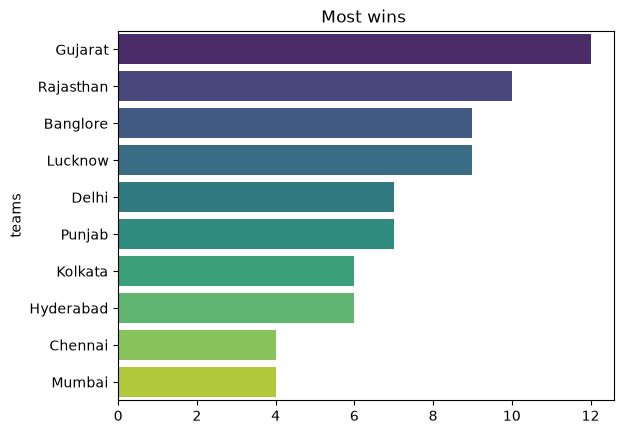

In [44]:
match_wins =df['match_winner'].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')
plt.title("Most wins ")
plt.ylabel("teams")
plt.savefig("most_win_matches.png", dpi=300, bbox_inches="tight")

Toss Decesion Trends 

C:\Users\dell\AppData\Local\Temp\ipykernel_9508\1353294092.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['toss_decision'],palette='rainbow')


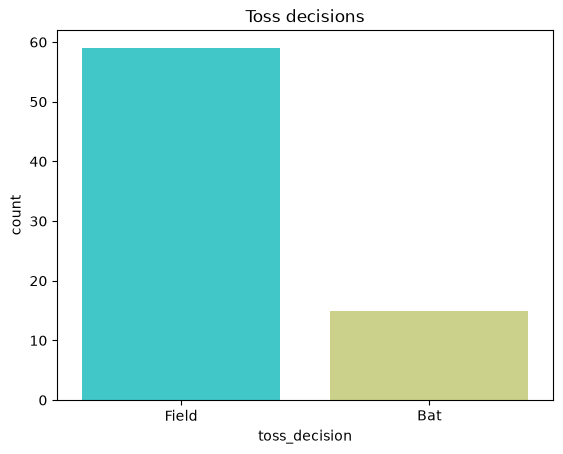

In [45]:
sns.countplot(x=df['toss_decision'],palette='rainbow')
plt.title("Toss decisions")
plt.savefig("toss_decision.png", dpi=300, bbox_inches="tight")

Toss winner vs Match winner

In [12]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage =(count*100)/df.shape[0]
percentage

np.float64(48.648648648648646)

How do team wins? (runs or wickets)

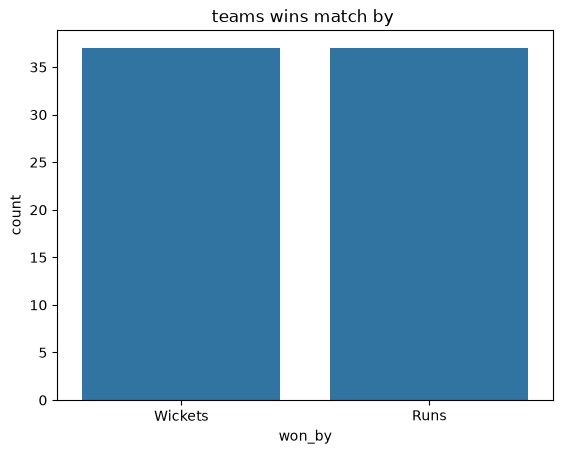

In [76]:
sns.countplot(x=df['won_by'])
plt.title('teams wins match by ')
plt.savefig("teams wins match by.png", dpi=300, bbox_inches="tight")

Key Player Performances 
1.Most "players of the match" award

C:\Users\dell\AppData\Local\Temp\ipykernel_3244\927938350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count.values,y=count.index,palette='mako')


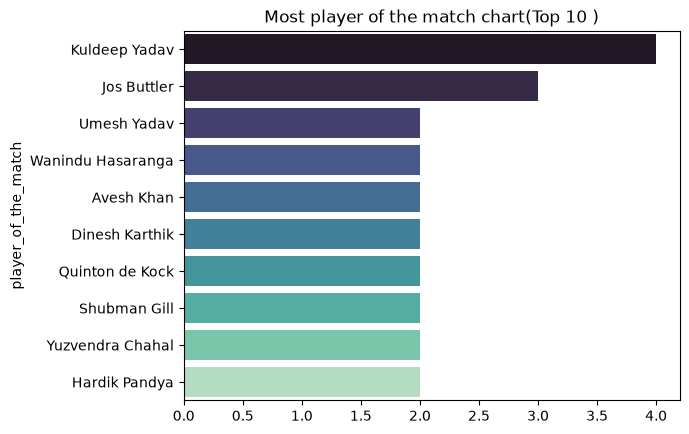

In [77]:
count=df['player_of_the_match'].value_counts().head(10)
count
sns.barplot(x=count.values,y=count.index,palette='mako')
plt.title("Most player of the match chart(Top 10 )")
plt.savefig("Most player of the match chart(top 10).png", dpi=300, bbox_inches="tight")

2.Tops Scorers 

In [27]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(10)
high

top_scorer
Jos Buttler         651
Quinton de Kock     377
KL Rahul            351
Shubman Gill        288
Faf du Plessis      257
Liam Livingstone    239
David Warner        213
W. Saha             190
Ishan Kishan        180
Shikhar Dhawan      158
Name: highscore, dtype: int64

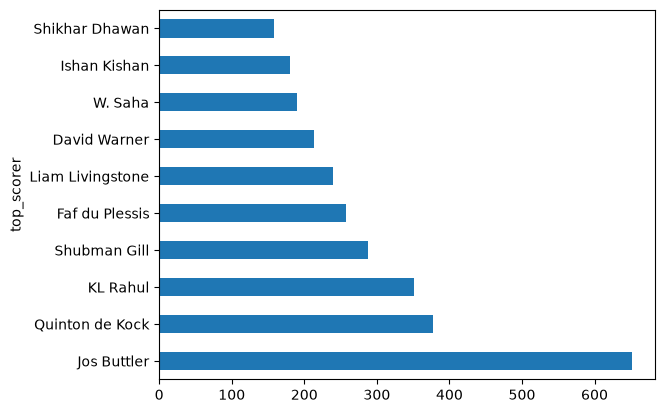

In [78]:
high.plot(kind='barh')
plt.savefig("Top scorer .png", dpi=300, bbox_inches="tight")

Best Bowling figures

In [45]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)

In [47]:
best_bowler=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
best_bowler

best_bowling
Yuzvendra Chahal     17
Jasprit Bumrah       11
Kuldeep Yadav        11
Rashid Khan          11
Josh Hazlewood       10
Kagiso Rabada        10
Avesh Khan           10
Umran Malik           9
Wanindu Hasaranga     9
T Natarajan           8
Name: highest_wickets, dtype: int64

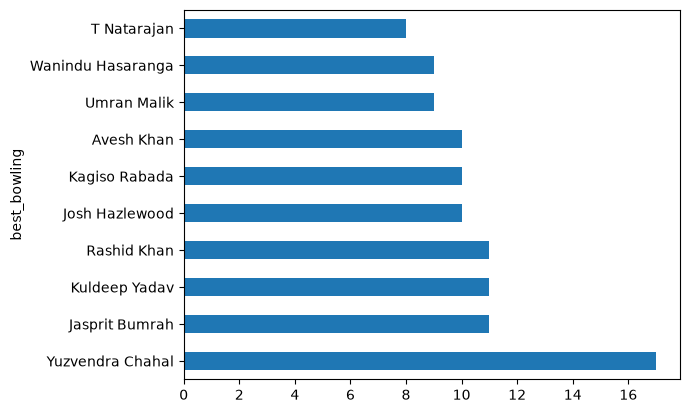

In [79]:
best_bowler.plot(kind="barh")
plt.savefig("Best Bowler.png", dpi=300, bbox_inches="tight")

Venue Analysis
Most Matches Played by Venue 

C:\Users\dell\AppData\Local\Temp\ipykernel_3244\782890557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=Most_used_stadium.index,x=Most_used_stadium.values,palette='rainbow')


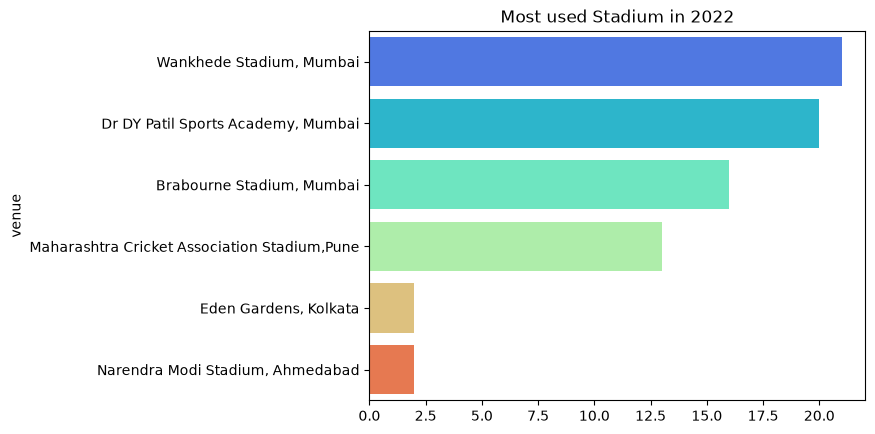

In [81]:
Most_used_stadium=df['venue'].value_counts()
Most_used_stadium
sns.barplot(y=Most_used_stadium.index,x=Most_used_stadium.values,palette='rainbow')
plt.title("Most used Stadium in 2022")
plt.savefig("Most used Stadium in 2022.png", dpi=300, bbox_inches="tight")

Who won the highest margin by runs ?

In [68]:
df[df['won_by']=='Runs'].sort_values(by='margin' ,ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Which player had the highest individual score?

In [73]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Which bowling Figure

In [75]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


what is the max score of the season and which team hit max score in  ipl 2022

In [13]:
mostrun=df['first_ings_score'].max()
# df[df['first_ings_score'] == mostrun]


df['batting_first'] = np.where(
    df['toss_decision'] == 'Bat',
    df['toss_winner'],
    np.where(df['toss_winner'] == df['team1'], df['team2'], df['team1'])
)

row = df.loc[df['first_ings_score'].idxmax()]

print(row['batting_first'])
print(row['first_ings_score'])

Rajasthan
222
